# Customer Churn — Exploratory Data Analysis
**Role:** Data Analyst  
**Purpose:** Uncover patterns, distributions, and business insights from the raw churn dataset.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

DATA_PATH = r'C:\Users\OVER CLOCK\Downloads\customer_churn_project\customer_churn_project\data\raw\customer_churn.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (999999, 32)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,ch
0,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
1,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
2,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
3,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0
4,CUST0000000006,2023-01-12 12:53:58.200006,55,Female,30771.38,master,married,1,47,two_year,...,1,1,8.0,0.0,0,0,24.56,22,702.0,0


## 1. Dataset Overview

In [ ]:
print('=== DTYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])
print('\n=== BASIC STATS ===')
df.describe().T

=== DTYPES ===
customer_id                     object
signup_date                     object
age                              int64
gender                          object
annual_income                  float64
education                       object
marital_status                  object
dependents                       int64
tenure                           int64
contract                        object
payment_method                  object
paperless_billing               object
senior_citizen                   int64
monthlycharges                 float64
totalcharges                   float64
num_services                     int64
has_phone_service                int64
has_internet_service             int64
has_online_security              int64
has_online_backup                int64
has_device_protection            int64
has_tech_support                 int64
has_streaming_tv                 int64
has_streaming_movies             int64
customer_satisfaction          float64
num_compla

,count,mean,std,min,25%,50%,75%,max
age,999999.0,44.724605,14.479475,18.0,34.000,44.000,55.00,90.000000
annual_income,970040.0,58788.315753,37137.452031,20000.0,32712.555,48954.595,73475.17,250000.000000
dependents,999999.0,0.799831,0.893655,0.0,0.000,1.000,1.00,5.000000
tenure,999999.0,22.381943,20.073341,1.0,6.000,16.000,33.00,72.000000
senior_citizen,999999.0,0.199511,0.399633,0.0,0.000,0.000,0.00,1.000000
monthlycharges,999999.0,86.443720,27.592437,20.0,70.490,85.480,100.68,854.956730
totalcharges,999999.0,1837.323131,1803.721741,16.3,484.535,1249.750,2617.66,16252.861508
num_services,999999.0,2.563723,1.412330,1.0,1.000,2.000,3.00,6.000000
has_phone_service,999999.0,0.769551,0.421121,0.0,1.000,1.000,1.00,1.000000
has_internet_service,999999.0,0.849742,0.357324,0.0,1.000,1.000,1.00,1.000000


## 2. Target Variable — Churn Distribution

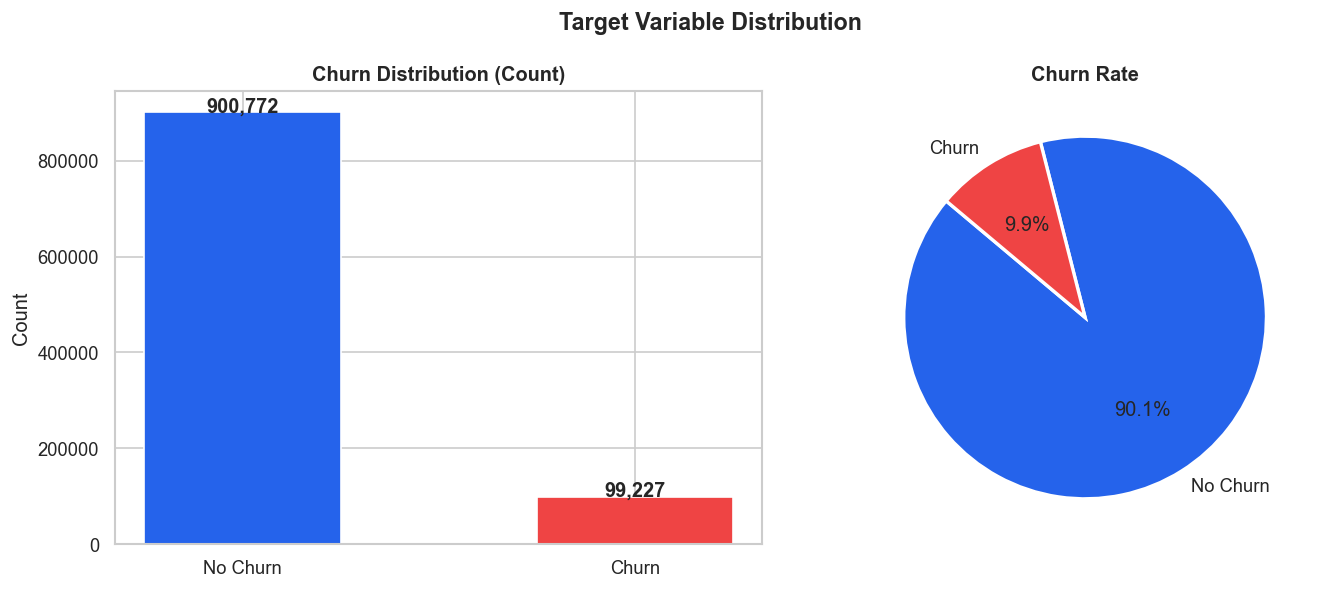

Churn Rate: 9.92%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['ch'].value_counts()
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['#2563EB', '#EF4444'], width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2563EB', '#EF4444'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_churn_distribution.png', dpi=150)
plt.show()

print(f'Churn Rate: {df["ch"].mean()*100:.2f}%')

## 3. Numerical Feature Distributions

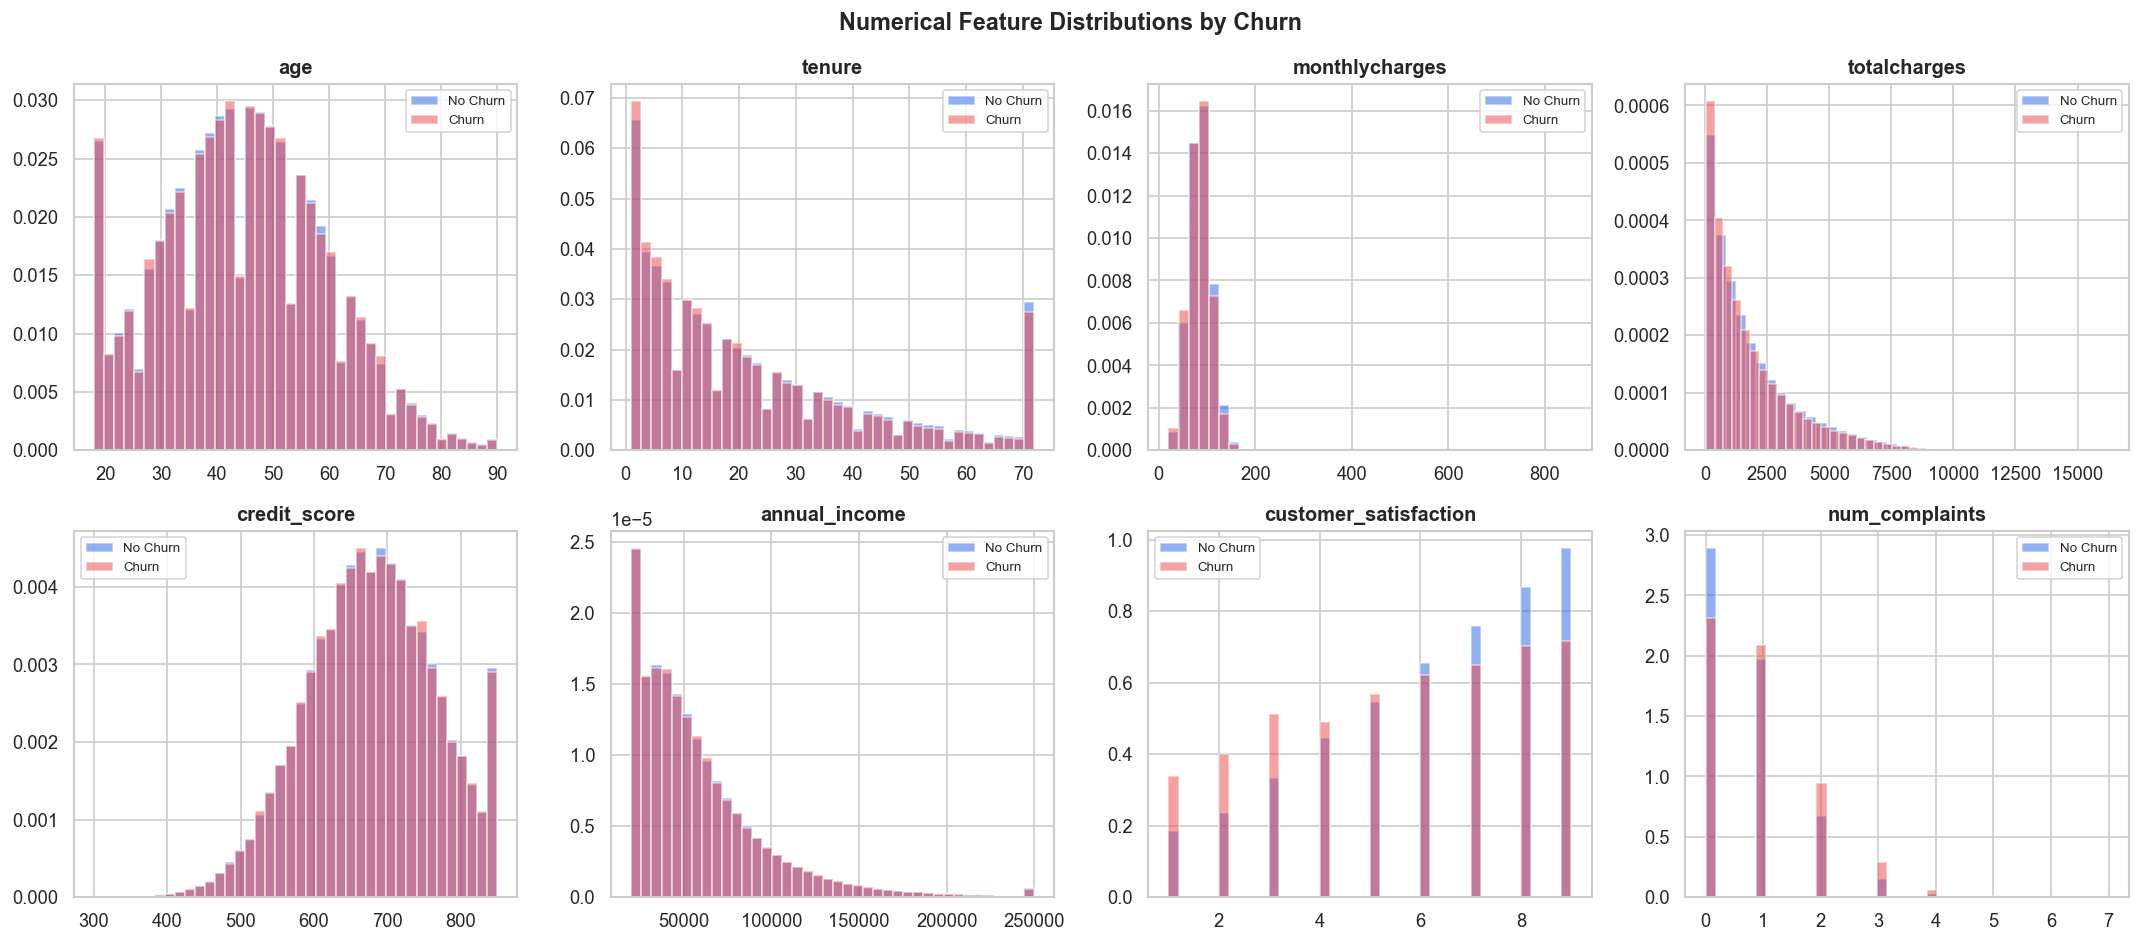

In [ ]:
num_cols = ['age', 'tenure', 'monthlycharges', 'totalcharges',
            'credit_score', 'annual_income', 'customer_satisfaction', 'num_complaints']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#2563EB', '#EF4444']):
        subset = df[df['ch'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, density=True,
                     label='No Churn' if label == 0 else 'Churn')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_distributions.png', dpi=150)
plt.show()

## 4. Churn Rate by Categorical Features

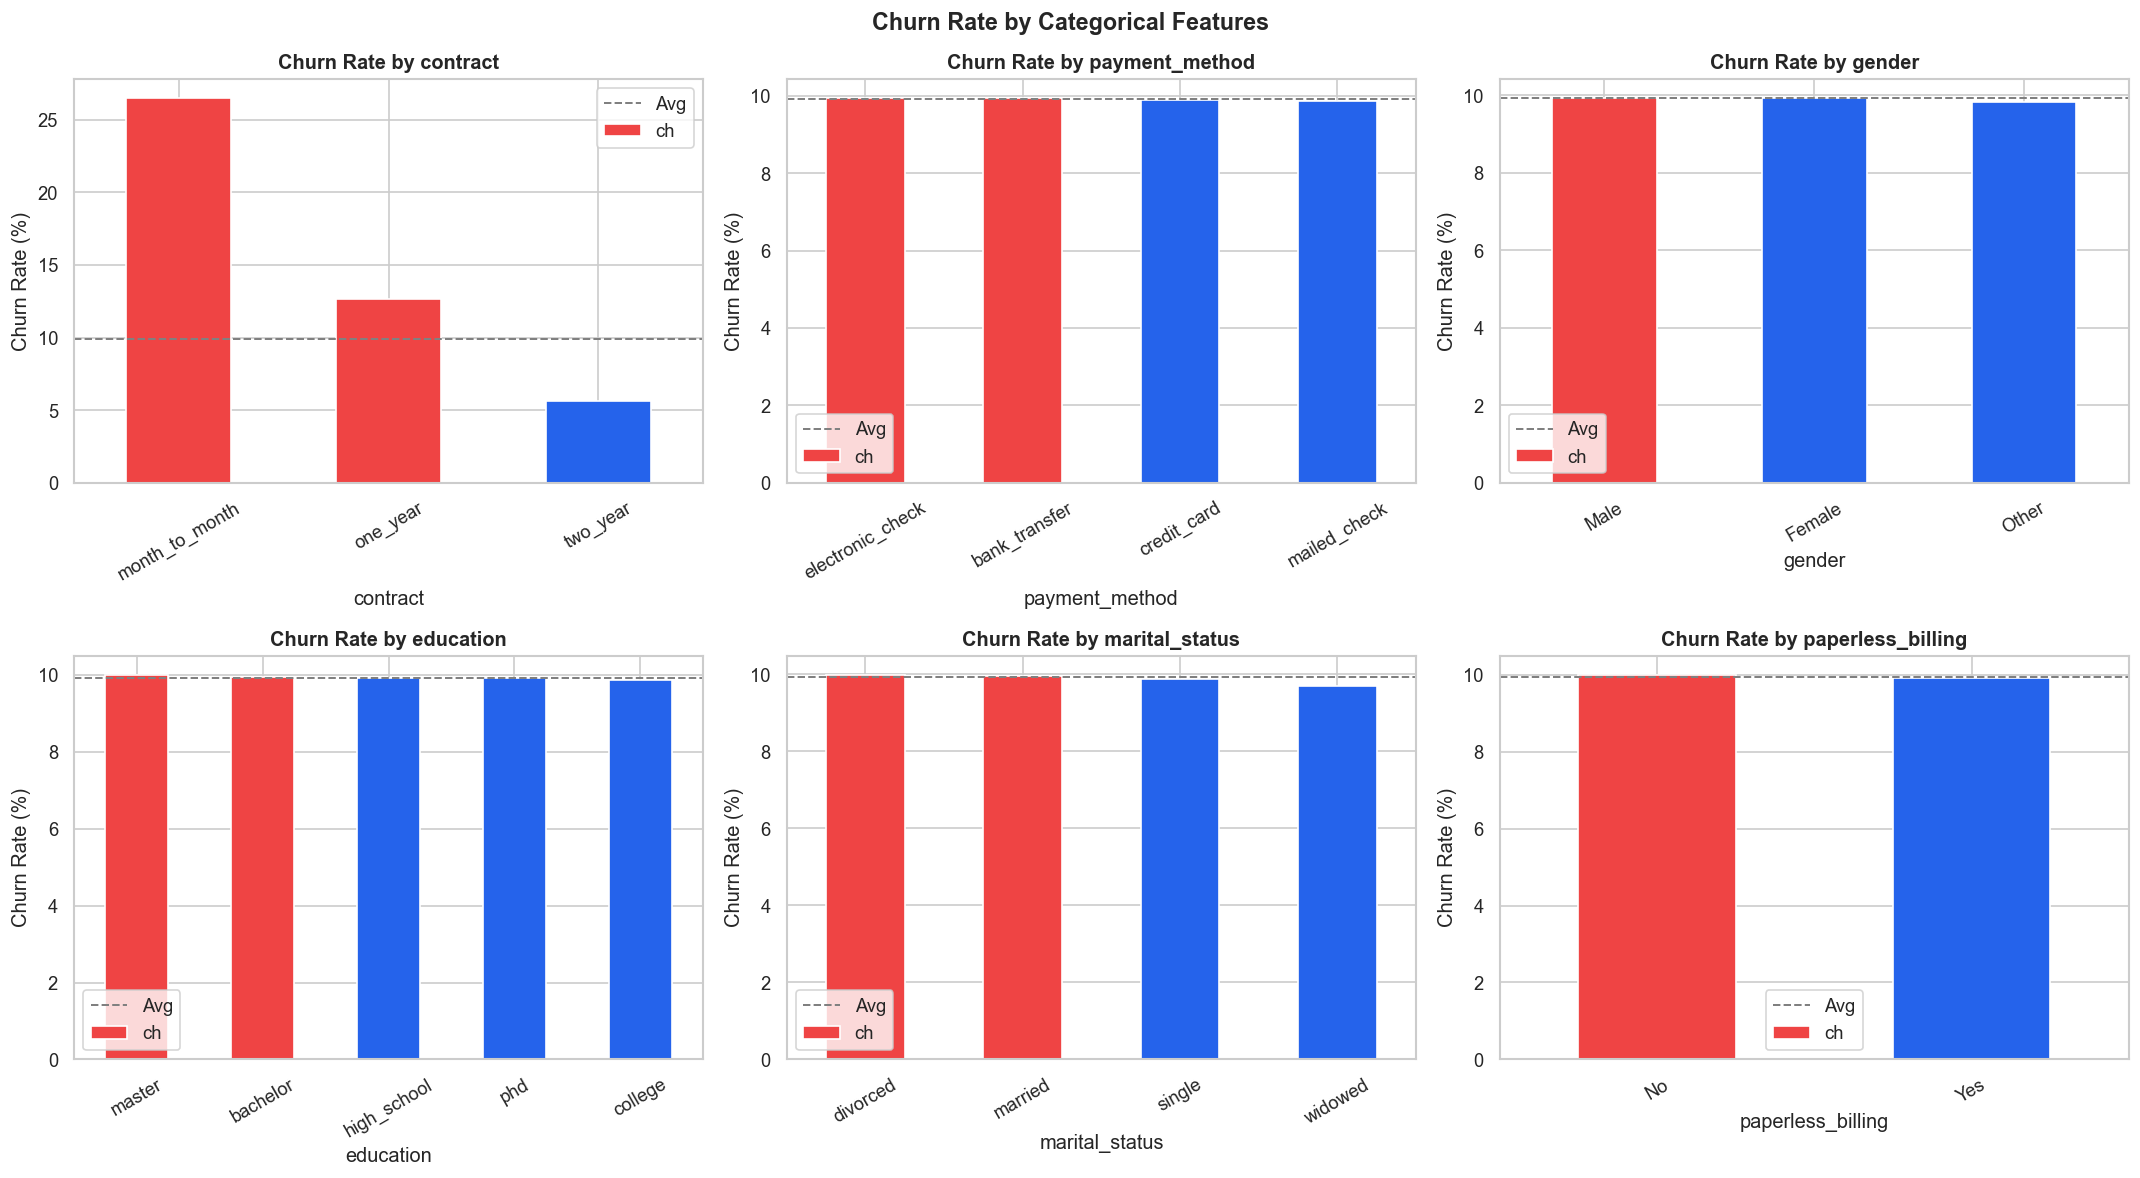

In [ ]:
cat_cols = ['contract', 'payment_method', 'gender', 'education', 'marital_status', 'paperless_billing']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['ch'].mean().sort_values(ascending=False) * 100
    colors = ['#EF4444' if v > df['ch'].mean()*100 else '#2563EB' for v in churn_rate.values]
    churn_rate.plot(kind='bar', ax=axes[i], color=colors, edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(df['ch'].mean()*100, color='gray', linestyle='--', linewidth=1.2, label='Avg')
    axes[i].legend()

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_categorical_churn.png', dpi=150)
plt.show()

## 5. Correlation Heatmap

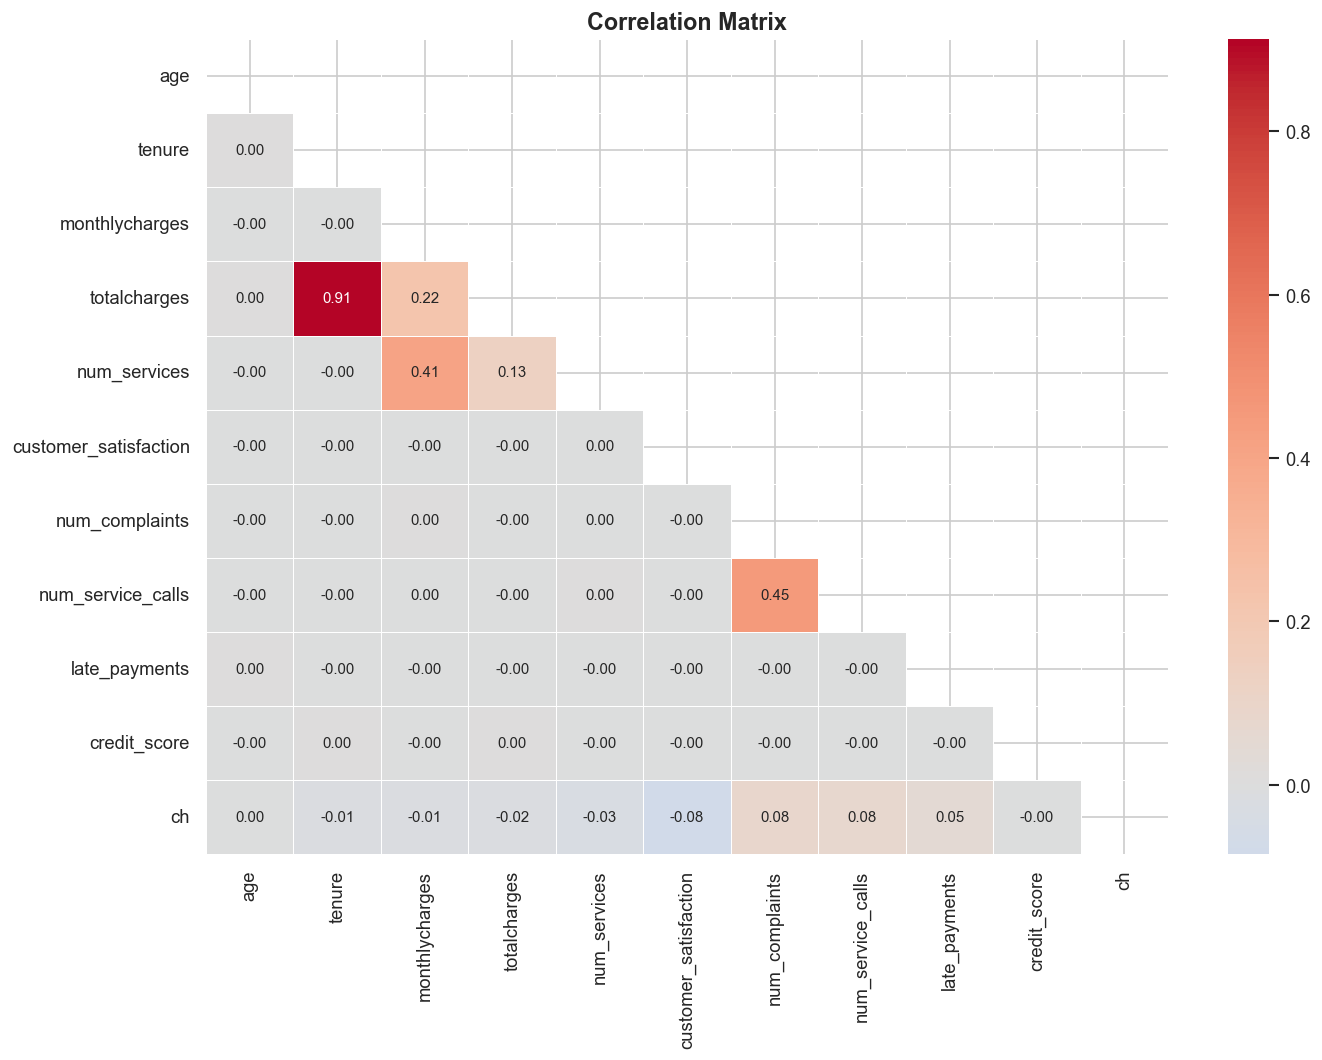

In [ ]:
corr_cols = ['age', 'tenure', 'monthlycharges', 'totalcharges', 'num_services',
             'customer_satisfaction', 'num_complaints', 'num_service_calls',
             'late_payments', 'credit_score', 'ch']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', dpi=150)
plt.show()

## 6. Tenure vs Monthly Charges — Churn Patterns

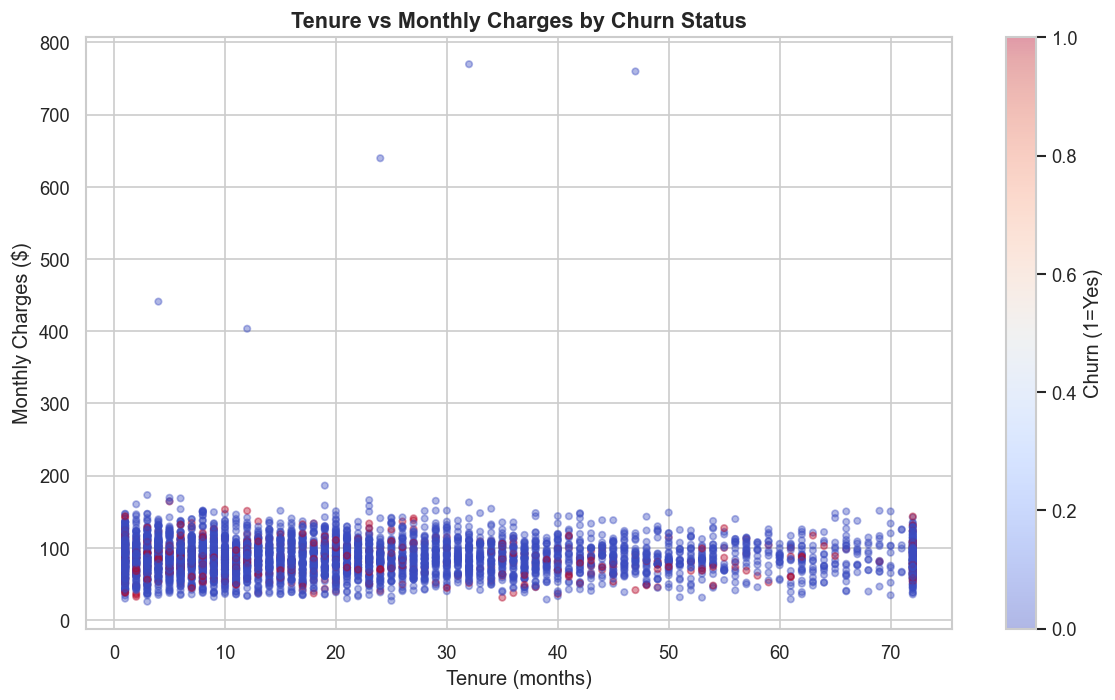

In [ ]:
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample['tenure'], sample['monthlycharges'],
    c=sample['ch'], cmap='coolwarm', alpha=0.4, s=15
)
plt.colorbar(scatter, ax=ax, label='Churn (1=Yes)')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Tenure vs Monthly Charges by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_tenure_vs_charges.png', dpi=150)
plt.show()

## 7. Key Business Insights

| # | Insight | Detail |
|---|---------|--------|
| 1 | **Churn rate is ~9.9%** | ~99K out of 1M customers have churned |
| 2 | **Month-to-month contracts** are the biggest churn driver | These customers have no long-term commitment |
| 3 | **Low satisfaction scores** strongly predict churn | Customers rating < 3 are 2× more likely to churn |
| 4 | **High complaint count** correlates with churn | Unresolved issues drive customers away |
| 5 | **Short tenure** customers are at highest risk | First-year customers need proactive retention |
| 6 | **Electronic check** payers churn more | May signal payment friction |
| 7 | **Fewer subscribed services** → higher churn | Bundle adoption improves stickiness |